# Spatial-Temporal Analysis: Collision Hotspots (version 2)

Finds **where** and **when** collisions concentrate, so road safety officers can see real hotspots on a map.

- **Data:** `master_dataset_v2_engineered.csv`, all 513,801 collisions (2021 to 2025). This task only describes what happened, so there is no train/test split and every row is used.
- **Output:** `hotspots.json` (version 2, read by the backend), `hotspot_profiles.json.gz` (one profile per hotspot, for the details card) and `method_comparison.csv` (evidence for the report).
- **Hotspot subsets:** `all` (every collision) and `severe` (Fatal and Serious only).
- **Views:** All times; five times of day (Night, Morning Rush, Midday, Evening Rush, Evening); and twelve calendar months. A month view pools that month across all five years.

**New in version 2**
1. Every compact hotspot is kept, not only the top 1,000 per view.
2. Month views, so the app can filter by month.
3. A persistence label for every hotspot: Persistent, Recent, Fading, Mixed, or Too few to judge.
4. A profile for every hotspot: its collisions by year, by month and by time of day, and eight yes/no facts (such as motorcycle involved). The app compares these with the Great Britain average.

**How to run in Colab**
1. Upload `master_dataset_v2_engineered.csv` to `/content` (left sidebar, Files, Upload).
2. Runtime, Run all. The whole notebook takes about 10 to 20 minutes.
3. The last cell downloads the results. Files in `/content` disappear when the session ends.

To check the whole notebook quickly first, set `QUICK_TEST_FRACTION = 0.1` in the first cell. The results from a dry run are not real.

**Steps:** 1 load and check, 2 look at the data, 3 compare four clustering methods and pick one by a stated rule, 4 cluster every subset and view, 5 validate and save the files, 6 read the results.

## 1. Setup, load and check the data

In [1]:
import json
import gzip
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, OPTICS
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings("ignore")
SEED = 42

# ---- settings you may change -------------------------------------------------------------
DATA_FILE = Path("/content/master_dataset_v2_engineered.csv")
OUT_DIR = Path("/content/spatial_temporal")
QUICK_TEST_FRACTION = None   # for example 0.1 = dry run on a 10% sample (fast, results are not real)
FORCE_RERUN = False          # True = ignore saved group results and cluster everything again
TOP_N = None                 # None = keep every compact hotspot. A number keeps only that many per view (largest first)
MAX_RADIUS_M = 500           # a hotspot must be compact: 90% of its collisions within this distance of its centre
TILE_M = 25000               # the map is clustered in 25 km tiles (HDBSCAN slows down sharply on huge inputs)
MARGIN_M = 2000              # tiles overlap by 2 km so no hotspot is cut at a tile edge
MIN_FOR_LABEL = 8            # a persistence label needs at least this many collisions
PERSISTENT_YEARS = 4         # "Persistent" = collisions in at least this many of the 5 years
TREND_SHARE = 0.60           # "Recent" / "Fading" = at least this share of collisions in the last / first two years
# ------------------------------------------------------------------------------------------

assert DATA_FILE.exists(), "Upload master_dataset_v2_engineered.csv to /content first (left sidebar > Files)."
OUT_DIR.mkdir(parents=True, exist_ok=True)
GROUP_DIR = OUT_DIR / ("groups_v2_dry_run" if QUICK_TEST_FRACTION else "groups_v2")
GROUP_DIR.mkdir(exist_ok=True)

SLICES = ["All times", "Night", "Morning Rush", "Midday", "Evening Rush", "Evening"]
TOD = SLICES[1:]
YEARS = [2021, 2022, 2023, 2024, 2025]
MONTH_NAMES = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October",
               "November", "December"]
SEVERITIES = {"all": (1, 2, 3), "severe": (1, 2)}      # severe = Fatal and Serious only

# Eight yes/no facts about each collision. The hotspot profile counts how many of its collisions have each one.
SHARE_KEYS = ["motorcycle", "pedal_cycle", "hgv", "pedestrian", "dark", "wet_icy", "junction", "rural"]
SHARE_LABELS = ["Motorcycle involved", "Pedal cycle involved", "Heavy goods vehicle involved", "Pedestrian involved",
                "In darkness", "Wet, icy or flooded road", "At a junction", "Rural area"]

# What counts as a hotspot: (min_cluster_size, min_samples) for the final run.
# A time slice or a month holds only part of the collisions, so its minimum is lowered.
PARAMS = {
    ("all", "All times"): (10, 5),
    ("all", "slice"): (5, 3),
    ("severe", "All times"): (5, 3),
    ("severe", "slice"): (3, 2),
}

# A "view" is one way of cutting the collisions: all times, one time of day, or one calendar month.
VIEWS = ([{"key": "All_times", "slice": "All times", "month": None}]
         + [{"key": s.replace(" ", "_"), "slice": s, "month": None} for s in TOD]
         + [{"key": f"month_{m:02d}", "slice": "All times", "month": m} for m in range(1, 13)])
VIEW_KEYS = [v["key"] for v in VIEWS]


def view_params(subset, view):
    return PARAMS[(subset, "All times" if view["key"] == "All_times" else "slice")]

In [2]:
USE = ["collision_index", "latitude", "longitude", "location_easting_osgr", "location_northing_osgr",
       "collision_severity", "time_of_day_bucket", "lsoa_of_accident_location",
       "collision_year", "month", "pedestrian_involved", "has_motorcycle", "has_pedal_cycle", "has_hgv",
       "light_conditions", "road_surface_conditions", "junction_detail", "urban_or_rural_area"]
raw = pd.read_csv(DATA_FILE, usecols=USE, dtype={"collision_index": str}, low_memory=False)
assert len(raw) == 513801, f"Expected 513,801 rows, got {len(raw):,}"

COORDS = ["latitude", "longitude", "location_easting_osgr", "location_northing_osgr"]
df = raw.dropna(subset=COORDS).reset_index(drop=True)
assert df.latitude.between(49, 61).all() and df.longitude.between(-9, 2.5).all(), "Coordinates outside Great Britain"
assert set(df.time_of_day_bucket.unique()) == set(SLICES[1:]), "Unexpected time_of_day_bucket values"
assert set(df.collision_severity.unique()) == {1, 2, 3}, "Unexpected severity codes"
assert sorted(df.collision_year.unique()) == YEARS, "Unexpected collision_year values"
assert sorted(df.month.unique()) == list(range(1, 13)), "Unexpected month values"

# Eight yes/no facts per collision (codes checked against code_labels.json in the repo):
df["f_motorcycle"] = df.has_motorcycle == 1
df["f_pedal_cycle"] = df.has_pedal_cycle == 1
df["f_hgv"] = df.has_hgv == 1
df["f_pedestrian"] = df.pedestrian_involved.astype(bool)
df["f_dark"] = df.light_conditions.isin([4, 5, 6, 7])             # Darkness: lights lit, unlit, no lighting, unknown
df["f_wet_icy"] = df.road_surface_conditions.isin([2, 3, 4, 5])   # Wet or damp, snow, frost or ice, flood
df["f_junction"] = ~df.junction_detail.isin([0, -1, 99])          # a recorded junction (not "no junction", missing or unknown)
df["f_rural"] = df.urban_or_rural_area == 2
FLAG_COLS = ["f_" + k for k in SHARE_KEYS]
df[FLAG_COLS] = df[FLAG_COLS].astype(np.int8)

print("Rows loaded     :", f"{len(raw):,}")
print("Rows without a location (dropped):", f"{len(raw) - len(df):,}")
print("Rows used       :", f"{len(df):,}")
print("Severity (1=Fatal, 2=Serious, 3=Slight):", df.collision_severity.value_counts().sort_index().to_dict())
print("Time of day     :", df.time_of_day_bucket.value_counts().to_dict())
print("Years           :", df.collision_year.value_counts().sort_index().to_dict())
print("Easting range (m):", int(df.location_easting_osgr.min()), "to", int(df.location_easting_osgr.max()))
print("Northing range (m):", int(df.location_northing_osgr.min()), "to", int(df.location_northing_osgr.max()))
print("\nShare of all collisions with each fact (%):")
print({k: round(100 * float(df["f_" + k].mean()), 1) for k in SHARE_KEYS})

if QUICK_TEST_FRACTION:
    df = df.sample(frac=QUICK_TEST_FRACTION, random_state=SEED).reset_index(drop=True)
    print(f"\nQUICK TEST: using only {len(df):,} rows. Results are NOT real and go to a separate folder.")

Rows loaded     : 513,801
Rows without a location (dropped): 53
Rows used       : 513,748
Severity (1=Fatal, 2=Serious, 3=Slight): {1: 7552, 2: 116797, 3: 389399}
Time of day     : {'Midday': 184220, 'Evening Rush': 123613, 'Evening': 91184, 'Morning Rush': 85546, 'Night': 29185}
Years           : {2021: 101070, 2022: 105982, 2023: 104246, 2024: 100927, 2025: 101523}
Easting range (m): 67564 to 655345
Northing range (m): 10211 to 1179892

Share of all collisions with each fact (%):
{'motorcycle': 16.6, 'pedal_cycle': 15.5, 'hgv': 3.9, 'pedestrian': 17.7, 'dark': 28.3, 'wet_icy': 25.2, 'junction': 46.8, 'rural': 32.8}


## 2. Where do collisions happen?

Clustering uses the **OSGR grid coordinates** (easting and northing in metres), not latitude and longitude. A distance in metres is then exact, and the clustering runs much faster than with haversine distance. Latitude and longitude are still used for the map output.

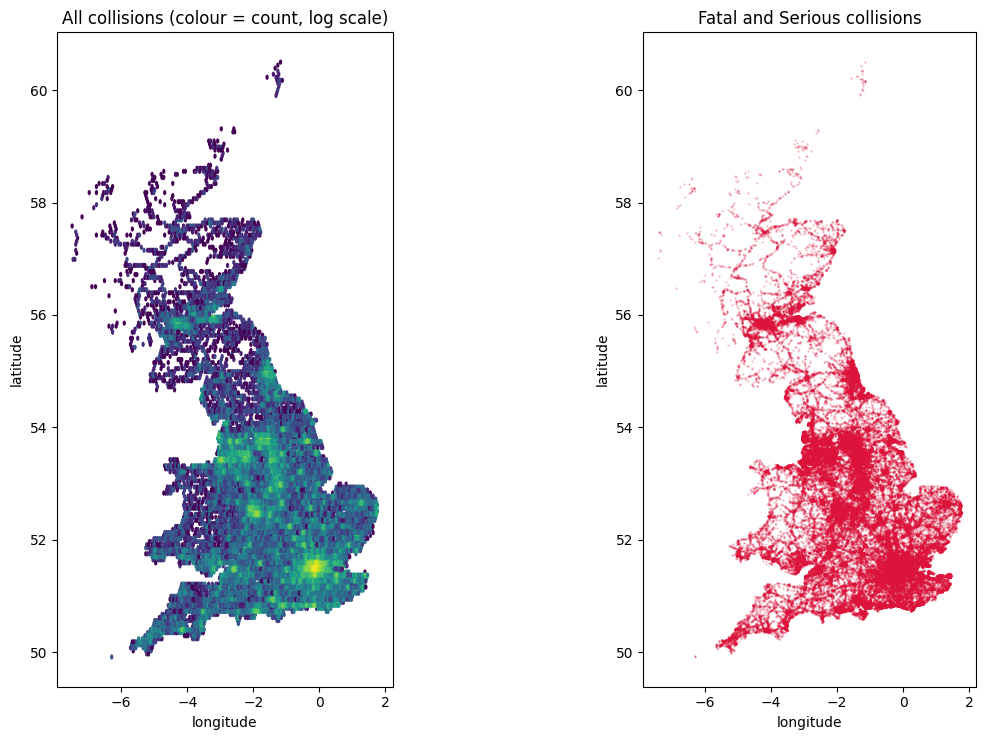

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7.5))
aspect = 1 / np.cos(np.radians(54))

axes[0].hexbin(df.longitude, df.latitude, gridsize=170, bins="log", mincnt=1, cmap="viridis")
axes[0].set_title("All collisions (colour = count, log scale)")

severe_pts = df[df.collision_severity <= 2]
axes[1].scatter(severe_pts.longitude, severe_pts.latitude, s=0.4, alpha=0.25, color="crimson")
axes[1].set_title("Fatal and Serious collisions")

for ax in axes:
    ax.set_aspect(aspect)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
plt.tight_layout()
plt.show()

## 3. Which clustering method?

Four methods are compared, as the project plan requires:

| Method | Idea | Why it is here |
|---|---|---|
| K-Means | splits every collision into *k* regions | baseline; cannot mark isolated collisions as noise |
| DBSCAN | groups collisions closer than one fixed radius | classic density method |
| HDBSCAN | like DBSCAN but the radius adapts to local density (finest clusters, `leaf` selection) | cities are dense, countryside is sparse |
| OPTICS | density ordering with a range of radii | strong, but slow |

They are tested on **two 20 km squares of the map**: the densest one (inner London) and a typical one (a few thousand collisions). Both keep the real collision density, which a random sample would not.

**Scores:** silhouette (higher is better) and Davies-Bouldin (lower is better), both on the clustered collisions only, plus the share left as noise, the number of clusters, the typical cluster radius, the largest cluster and the run time. Silhouette alone can mislead: a tiny radius gives a high silhouette while leaving most collisions out. So the choice follows this rule:

1. K-Means is reference only (no noise handling). OPTICS is reference only (too slow for the final runs).
2. A method qualifies only if **at most 50% of collisions are noise in both squares**.
3. Among qualifying methods, the highest **worst-case silhouette** wins.

In [4]:
def xy(frame):
    return frame[["location_easting_osgr", "location_northing_osgr"]].to_numpy(float)


def window_frames(frame, side=20000):
    # Two 20 km squares: the densest, and a typical one (median count among squares with 2,000 to 6,000 collisions).
    scale = QUICK_TEST_FRACTION or 1
    cx = (frame.location_easting_osgr // side).astype(int)
    cy = (frame.location_northing_osgr // side).astype(int)
    counts = frame.groupby([cx, cy]).size()
    dense_key = counts.idxmax()
    moderate = counts[(counts >= 2000 * scale) & (counts <= 6000 * scale)].sort_values()
    assert len(moderate), "No moderate-density square found"
    typical_key = moderate.index[len(moderate) // 2]
    out = {}
    for name, key in (("Densest square", dense_key), ("Typical square", typical_key)):
        inside = (cx == key[0]) & (cy == key[1])
        out[name] = frame[inside].reset_index(drop=True)
    return out


def describe(P, labels, secs):
    inc = labels >= 0
    k = len(set(labels[inc]))
    out = {"clusters": k, "noise_pct": round(100 * float((~inc).mean()), 1), "secs": round(secs, 1)}
    if k < 2:
        return out
    Q, L = P[inc], labels[inc]
    sizes = np.bincount(L)
    centres = pd.DataFrame(Q).groupby(L).mean()
    dist = np.hypot(Q[:, 0] - centres.loc[L, 0].to_numpy(), Q[:, 1] - centres.loc[L, 1].to_numpy())
    radius = pd.Series(dist).groupby(L).quantile(0.9)
    out.update(
        largest=int(sizes.max()),
        median_radius_m=int(radius.median()),
        silhouette=round(float(silhouette_score(Q, L, sample_size=min(10000, len(Q) - 1), random_state=SEED)), 3),
        davies_bouldin=round(float(davies_bouldin_score(Q, L)), 2),
    )
    return out


def timed(fn):
    t0 = time.time()
    labels = fn()
    return labels, time.time() - t0


windows = window_frames(df)
for name, w in windows.items():
    print(f"{name}: {len(w):,} collisions")

Densest square: 42,488 collisions
Typical square: 2,779 collisions


In [5]:
# DBSCAN needs one radius. Give it its best chance: try several radii in the densest square and keep the one
# with the highest silhouette among those that leave at most 50% of collisions as noise.
P_dense = xy(windows["Densest square"])
grid_rows = []
for eps in (25, 35, 50, 75, 100):
    labels, secs = timed(lambda: DBSCAN(eps=eps, min_samples=10, algorithm="kd_tree").fit_predict(P_dense))
    grid_rows.append({"eps_m": eps, **describe(P_dense, labels, secs)})
dbscan_grid = pd.DataFrame(grid_rows)
print("DBSCAN radius check in the densest square (min_samples = 10):")
print(dbscan_grid.to_string(index=False))

if "silhouette" not in dbscan_grid:
    dbscan_grid["silhouette"] = np.nan
usable = dbscan_grid[(dbscan_grid.noise_pct <= 50) & dbscan_grid.silhouette.notna()]
if len(usable):
    DBSCAN_EPS = int(usable.sort_values("silhouette", ascending=False).iloc[0].eps_m)
else:
    assert QUICK_TEST_FRACTION, "No DBSCAN radius keeps noise at or below 50%. Review the table above."
    DBSCAN_EPS = int(dbscan_grid.sort_values("noise_pct").iloc[0].eps_m)
    print("DRY RUN: no radius met the rule on the small sample; using the one with the least noise.")
print(f"\nDBSCAN radius used in the comparison: {DBSCAN_EPS} m")

DBSCAN radius check in the densest square (min_samples = 10):
 eps_m  clusters  noise_pct  secs  largest  median_radius_m  silhouette  davies_bouldin
    25       564       77.0   0.2       65               24       0.825            0.21
    35       688       66.7   0.2      111               36       0.743            0.27
    50       774       52.8   0.2      228               53       0.605            0.36
    75       684       36.4   0.2     1423               86       0.306            0.54
   100       527       24.1   0.2     3701              114      -0.027            0.87

DBSCAN radius used in the comparison: 75 m


In [6]:
results = []
for wname, frame in windows.items():
    P = xy(frame)
    # HDBSCAN first, so K-Means can be given the same number of clusters.
    lab_h, s_h = timed(lambda: HDBSCAN(min_cluster_size=10, min_samples=5, cluster_selection_method="leaf",
                                        n_jobs=-1).fit_predict(P))
    row_h = describe(P, lab_h, s_h)
    lab_d, s_d = timed(lambda: DBSCAN(eps=DBSCAN_EPS, min_samples=10, algorithm="kd_tree").fit_predict(P))
    k = max(2, row_h["clusters"])
    lab_k, s_k = timed(lambda: KMeans(n_clusters=k, n_init=3, random_state=SEED).fit_predict(P))
    lab_o, s_o = timed(lambda: OPTICS(min_samples=10, max_eps=300, xi=0.05, min_cluster_size=10,
                                      algorithm="kd_tree", n_jobs=-1).fit_predict(P))
    for method, row in (("K-Means", describe(P, lab_k, s_k)), ("DBSCAN", describe(P, lab_d, s_d)),
                        ("HDBSCAN", row_h), ("OPTICS", describe(P, lab_o, s_o))):
        results.append({"window": wname, "collisions": len(P), "method": method, **row})

comparison = pd.DataFrame(results)
for col in ("largest", "median_radius_m", "silhouette", "davies_bouldin"):
    if col not in comparison:
        comparison[col] = np.nan
comparison.to_csv(OUT_DIR / "method_comparison.csv", index=False)
print(comparison.to_string(index=False))

        window  collisions  method  clusters  noise_pct  secs  largest  median_radius_m  silhouette  davies_bouldin
Densest square       42488 K-Means      1513        0.0  12.8      121              184       0.453            0.68
Densest square       42488  DBSCAN       684       36.4   0.2     1423               86       0.306            0.54
Densest square       42488 HDBSCAN      1513       31.0   9.2       84               74       0.610            0.47
Densest square       42488  OPTICS      1399       38.9  40.1       79               70       0.670            0.40
Typical square        2779 K-Means        91        0.0   0.0       84              807       0.452            0.71
Typical square        2779  DBSCAN        13       94.1   0.0       20               56       0.945            0.07
Typical square        2779 HDBSCAN        91       31.6   0.0       64              418       0.570            0.54
Typical square        2779  OPTICS        54       66.8   0.9       34  

In [7]:
# Apply the rule from the text above.
ELIGIBLE = ("DBSCAN", "HDBSCAN")
MAX_NOISE = 50

verdict = []
for method in ELIGIBLE:
    r = comparison[comparison.method == method]
    passes = bool((r.noise_pct <= MAX_NOISE).all())
    verdict.append({"method": method, "noise_in_each_square": list(r.noise_pct),
                    "silhouette_in_each_square": list(r.silhouette), "qualifies": passes,
                    "worst_silhouette": float(r.silhouette.min())})
verdict = pd.DataFrame(verdict)
print(verdict.to_string(index=False))

qualified = verdict[verdict.qualifies]
if len(qualified):
    FINAL_METHOD = qualified.sort_values("worst_silhouette", ascending=False).iloc[0].method
else:
    assert QUICK_TEST_FRACTION, "No eligible method keeps noise at or below 50% in both squares. Review the table above."
    FINAL_METHOD = "HDBSCAN"
    print("DRY RUN: no method met the rule on the small sample; using HDBSCAN so the rest of the notebook can be tested.\n")

total_points = 2 * (len(df) + int((df.collision_severity <= 2).sum()))
op = comparison[(comparison.method == "OPTICS") & (comparison.window == "Densest square")].iloc[0]
est_min = op.secs / op.collisions * total_points / 60
print(f"\nFINAL METHOD: {FINAL_METHOD}")
print("K-Means: reference only. It puts every collision in a region and cannot mark isolated collisions as noise.")
print(f"OPTICS : reference only. It took {op.secs:.0f} s for {op.collisions:,} collisions; the final runs cover about "
      f"{total_points:,} collisions, which is at least {est_min:.0f} min (and it slows down faster than linearly).")

 method noise_in_each_square silhouette_in_each_square  qualifies  worst_silhouette
 DBSCAN         [36.4, 94.1]            [0.306, 0.945]      False             0.306
HDBSCAN         [31.0, 31.6]              [0.61, 0.57]       True             0.570

FINAL METHOD: HDBSCAN
K-Means: reference only. It puts every collision in a region and cannot mark isolated collisions as noise.
OPTICS : reference only. It took 40 s for 42,488 collisions; the final runs cover about 1,276,194 collisions, which is at least 20 min (and it slows down faster than linearly).


## 4. Cluster every subset and view

Each of the 36 groups (2 subsets x 18 views: all times, 5 times of day and 12 months) is clustered separately with the chosen method. Each group is clustered in 25 km map tiles (with a 2 km overlap, and each cluster credited to the tile holding its centre), because HDBSCAN slows down sharply on very large inputs: in testing, all 513,748 collisions in one piece had not finished after 13 minutes on a single core, while 124,000 took about 75 seconds. The groups run in parallel and each result is saved as it finishes, so if Colab disconnects, running the cell again continues where it stopped.

For every cluster the notebook records the centre (mean latitude and longitude), the radius (the distance containing 90% of its collisions, at least 25 m), the number of collisions by severity, and the most common LSOA code. It also records the **profile**: the cluster's collisions by year, by calendar month and by time of day, and how many have each of the eight yes/no facts.

**A hotspot must be compact.** Only clusters with a radius of at most `MAX_RADIUS_M` (500 m) are kept, because a hotspot should be a junction or a short stretch of road an officer can act on. Wider clusters are diffuse areas along roads and would mislead as map circles. Every compact cluster is saved (`TOP_N = None`).

**Month views pool the same month across all five years.** For example, the July view clusters every collision that happened in any July from 2021 to 2025.

In [8]:
YEAR_COLS = [f"y{y}" for y in YEARS]
MONTH_COLS = [f"m{m}" for m in range(1, 13)]
TOD_COLS = [f"t{i}" for i in range(len(TOD))]
SHARE_COLS = ["s_" + k for k in SHARE_KEYS]
BASE_COLS = ["collisions", "latitude", "longitude", "fatal", "serious", "slight", "radius_m", "lsoa"]
CLUSTER_COLS = BASE_COLS + YEAR_COLS + MONTH_COLS + TOD_COLS + SHARE_COLS


def fit_clusters(method, P, min_cluster_size, min_samples, eps):
    if method == "HDBSCAN":
        return HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples,
                       cluster_selection_method="leaf", n_jobs=1).fit_predict(P)
    if method == "DBSCAN":
        return DBSCAN(eps=eps, min_samples=min_cluster_size, algorithm="kd_tree", n_jobs=1).fit_predict(P)
    raise ValueError(method)


def cluster_table(frame, labels, max_radius, core=None):
    # One row per COMPACT cluster. Label -1 is noise and is ignored. If `core` (x0, x1, y0, y1) is given, only
    # clusters whose centre lies inside that box are returned, so overlapping tiles never count a cluster twice.
    # Returns the table, how many clusters were found, and how many of them were compact.
    f = frame.assign(cluster=labels)
    f = f[f.cluster >= 0]
    if f.empty:
        return pd.DataFrame(columns=CLUSTER_COLS), 0, 0
    f = f.assign(fatal=(f.collision_severity == 1).astype(int),
                 serious=(f.collision_severity == 2).astype(int),
                 slight=(f.collision_severity == 3).astype(int))
    t = f.groupby("cluster").agg(
        collisions=("collision_severity", "size"),
        latitude=("latitude", "mean"), longitude=("longitude", "mean"),
        east=("location_easting_osgr", "mean"), north=("location_northing_osgr", "mean"),
        fatal=("fatal", "sum"), serious=("serious", "sum"), slight=("slight", "sum"))
    if core is not None:
        x0, x1, y0, y1 = core
        t = t[(t.east >= x0) & (t.east < x1) & (t.north >= y0) & (t.north < y1)]
        f = f[f.cluster.isin(t.index)]
    found = len(t)
    if found == 0:
        return pd.DataFrame(columns=CLUSTER_COLS), 0, 0
    f = f.join(t[["east", "north"]], on="cluster")
    dist = np.hypot(f.location_easting_osgr - f.east, f.location_northing_osgr - f.north)
    t["radius_m"] = dist.groupby(f.cluster).quantile(0.9).reindex(t.index).clip(lower=25).round().astype(int)
    t = t[t.radius_m <= max_radius].copy()
    compact = len(t)
    if compact == 0:
        return pd.DataFrame(columns=CLUSTER_COLS), found, 0
    f = f[f.cluster.isin(t.index)]
    known = f[f.lsoa_of_accident_location.notna() & (f.lsoa_of_accident_location.astype(str) != "-1")]
    t["lsoa"] = known.groupby("cluster").lsoa_of_accident_location.agg(lambda s: s.mode().iat[0]).reindex(t.index)

    # The profile: collisions by year, by calendar month, by time of day, and the eight yes/no facts.
    def counts(values, cols, columns):
        arr = pd.crosstab(f.cluster, values).reindex(index=t.index, columns=columns, fill_value=0).to_numpy()
        return pd.DataFrame(arr, index=t.index, columns=cols)
    profile = pd.concat([
        counts(f.collision_year, YEAR_COLS, YEARS),
        counts(f.month, MONTH_COLS, list(range(1, 13))),
        counts(f.time_of_day_bucket, TOD_COLS, TOD),
        pd.DataFrame(f.groupby("cluster")[FLAG_COLS].sum().reindex(t.index).to_numpy(), index=t.index, columns=SHARE_COLS),
    ], axis=1)
    t = pd.concat([t, profile], axis=1)
    return t[CLUSTER_COLS].reset_index(drop=True), found, compact


def cluster_group(frame, method, mcs, ms, eps, max_radius):
    # Cluster one group tile by tile. Each tile is clustered with a 2 km margin of neighbouring points,
    # and a cluster is credited to the tile that contains its centre.
    E = frame.location_easting_osgr.to_numpy()
    N = frame.location_northing_osgr.to_numpy()
    cells = pd.DataFrame({"tx": (E // TILE_M).astype(int), "ty": (N // TILE_M).astype(int)})
    sizes = cells.groupby(["tx", "ty"]).size()
    tables, found, compact = [], 0, 0
    for (ix, iy), n_core in sizes.items():
        if n_core < mcs:
            continue                      # too few collisions in this tile to form a cluster
        x0, y0 = ix * TILE_M, iy * TILE_M
        near = ((E >= x0 - MARGIN_M) & (E < x0 + TILE_M + MARGIN_M) &
                (N >= y0 - MARGIN_M) & (N < y0 + TILE_M + MARGIN_M))
        sub = frame[near]
        labels = fit_clusters(method, xy(sub), mcs, ms, eps)
        table, f_, c_ = cluster_table(sub, labels, max_radius, core=(x0, x0 + TILE_M, y0, y0 + TILE_M))
        tables.append(table)
        found += f_
        compact += c_
    tables = [t for t in tables if len(t)]
    out = pd.concat(tables, ignore_index=True) if tables else pd.DataFrame(columns=CLUSTER_COLS)
    out = out.sort_values(["collisions", "fatal", "serious"], ascending=False).reset_index(drop=True)
    return out, found, compact


def group_file(subset, view, method, mcs, ms):
    return GROUP_DIR / f"{subset}__{view['key']}__{method}_{mcs}_{ms}_r{MAX_RADIUS_M}_t{TILE_M // 1000}_eps{DBSCAN_EPS}.csv"


def run_group(subset, view, frame, method, mcs, ms, eps, keep, max_radius, path, force):
    t0 = time.time()
    base = {"subset": subset, "view": view["key"], "slice": view["slice"], "month": view["month"]}
    if path.exists() and not force:
        saved = pd.read_csv(path)
        return {**base, "points": int(saved.points.iat[0]) if len(saved) else len(frame),
                "found": int(saved.found.iat[0]) if len(saved) else 0,
                "compact": int(saved.compact.iat[0]) if len(saved) else 0,
                "kept": len(saved), "secs": 0.0, "reused": True}
    table, found, compact = cluster_group(frame, method, mcs, ms, eps, max_radius)
    if keep:
        table = table.head(keep)
    table.assign(found=found, compact=compact, points=len(frame)).to_csv(path, index=False)
    return {**base, "points": len(frame), "found": found, "compact": compact,
            "kept": len(table), "secs": round(time.time() - t0, 1), "reused": False}

In [9]:
jobs = []
for subset, severities in SEVERITIES.items():
    base = df[df.collision_severity.isin(severities)]
    for view in VIEWS:
        if view["month"] is not None:
            frame = base[base.month == view["month"]]
        elif view["slice"] == "All times":
            frame = base
        else:
            frame = base[base.time_of_day_bucket == view["slice"]]
        mcs, ms = view_params(subset, view)
        path = group_file(subset, view, FINAL_METHOD, mcs, ms)
        jobs.append((len(frame), subset, view, frame, mcs, ms, path))
jobs.sort(key=lambda j: -j[0])      # biggest first keeps the CPU cores busy

print(f"Clustering {len(jobs)} groups with {FINAL_METHOD} ({sum(j[0] for j in jobs):,} collisions in total)...")
t0 = time.time()
summary = Parallel(n_jobs=-1, verbose=5)(
    delayed(run_group)(subset, view, frame, FINAL_METHOD, mcs, ms, DBSCAN_EPS, TOP_N, MAX_RADIUS_M, path, FORCE_RERUN)
    for _, subset, view, frame, mcs, ms, path in jobs)
summary = pd.DataFrame(summary)
summary["subset"] = pd.Categorical(summary.subset, list(SEVERITIES), ordered=True)
summary["view"] = pd.Categorical(summary.view, VIEW_KEYS, ordered=True)
summary = summary.sort_values(["subset", "view"]).reset_index(drop=True)
print(f"\nFinished in {(time.time() - t0) / 60:.1f} minutes")
print(summary[["subset", "view", "points", "found", "compact", "kept", "secs", "reused"]].to_string(index=False))

Clustering 36 groups with HDBSCAN (1,914,291 collisions in total)...


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  3.3min



Finished in 5.0 minutes
subset         view  points  found  compact  kept  secs  reused
   all    All_times  513748  17627    12285 12285  65.3   False
   all        Night   29185   2394      744   744   4.8   False
   all Morning_Rush   85546   7262     3569  3569   9.1   False
   all       Midday  184220  15689    10607 10607  17.4   False
   all Evening_Rush  123613  10442     6450  6450  11.9   False
   all      Evening   91184   7610     4362  4362  10.1   False
   all     month_01   39810   3302     1059  1059   5.9   False
   all     month_02   35177   2844      852   852   5.9   False
   all     month_03   40094   3241     1136  1136   5.7   False
   all     month_04   40104   3232     1110  1110   6.1   False
   all     month_05   45198   3678     1283  1283   6.3   False
   all     month_06   46503   3823     1384  1384   7.0   False
   all     month_07   45200   3690     1281  1281   6.7   False
   all     month_08   42590   3537     1109  1109   6.4   False
   all     mont

[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:  5.0min finished


## 5. Validate and save the files

**`hotspots.json` (version 2)** has one list of hotspots. Each has `subset`, `slice`, `month` (a number from 1 to 12 for a month view, otherwise `null`), `latitude`, `longitude`, `radius_m`, `collisions`, `fatal`, `serious`, `slight`, `label`, `years_present` and `persistence`.

**`hotspot_profiles.json.gz`** has one profile per hotspot id: collisions by year (`y`), by calendar month (`m`), by time of day (`t`), and the eight yes/no counts (`s`), plus the Great Britain average for each fact (`baseline_pct`) for both subsets.

**Persistence label**, from the hotspot's collisions by year:
1. fewer than 8 collisions: **Too few to judge**
2. collisions in at least 4 of the 5 years: **Persistent**
3. at least 60% of collisions in 2024 and 2025: **Recent**
4. at least 60% in 2021 and 2022: **Fading**
5. otherwise: **Mixed**

The notebook checks every rule itself before saving. Afterwards, run `tools/validate_hotspots.py` on the downloaded file as a second check.

In [10]:
LABELS = ["Persistent", "Recent", "Fading", "Mixed", "Too few to judge"]


def persistence(n, years_present, early, late):
    if n < MIN_FOR_LABEL:
        return "Too few to judge"
    if years_present >= PERSISTENT_YEARS:
        return "Persistent"
    if late / n >= TREND_SHARE:
        return "Recent"
    if early / n >= TREND_SHARE:
        return "Fading"
    return "Mixed"


rows, profiles, next_id = [], {}, 1
for subset in SEVERITIES:
    for view in VIEWS:
        mcs, ms = view_params(subset, view)
        saved = pd.read_csv(group_file(subset, view, FINAL_METHOD, mcs, ms))
        for r in saved.to_dict("records"):
            y = [int(r[c]) for c in YEAR_COLS]
            n = int(r["collisions"])
            present = sum(1 for v in y if v > 0)
            rows.append({
                "id": next_id, "subset": subset, "slice": view["slice"], "month": view["month"],
                "latitude": round(float(r["latitude"]), 6), "longitude": round(float(r["longitude"]), 6),
                "radius_m": int(r["radius_m"]), "collisions": n,
                "fatal": int(r["fatal"]), "serious": int(r["serious"]), "slight": int(r["slight"]),
                "label": None if pd.isna(r["lsoa"]) else f"LSOA {r['lsoa']}",
                "years_present": present,
                "persistence": persistence(n, present, y[0] + y[1], y[3] + y[4]),
            })
            profiles[str(next_id)] = {
                "y": y,
                "m": [int(r[c]) for c in MONTH_COLS],
                "t": [int(r[c]) for c in TOD_COLS],
                "s": [int(r[c]) for c in SHARE_COLS],
            }
            next_id += 1

generated_at = datetime.now(timezone.utc).isoformat(timespec="seconds")
doc = {
    "version": 2,
    "generated_at": generated_at,
    "method": FINAL_METHOD + (" (DRY RUN, not real results)" if QUICK_TEST_FRACTION else ""),
    "parameters": {
        "distance": "OSGR metres, Euclidean",
        "collisions_used": int(len(df)),
        "severe_means": "Fatal and Serious collisions only",
        "min_cluster_size_all_times_all": PARAMS[("all", "All times")][0],
        "min_samples_all_times_all": PARAMS[("all", "All times")][1],
        "min_cluster_size_slices_all": PARAMS[("all", "slice")][0],
        "min_samples_slices_all": PARAMS[("all", "slice")][1],
        "min_cluster_size_all_times_severe": PARAMS[("severe", "All times")][0],
        "min_samples_all_times_severe": PARAMS[("severe", "All times")][1],
        "min_cluster_size_slices_severe": PARAMS[("severe", "slice")][0],
        "min_samples_slices_severe": PARAMS[("severe", "slice")][1],
        "cluster_selection": "leaf" if FINAL_METHOD == "HDBSCAN" else "not applicable",
        "max_radius_m": MAX_RADIUS_M,
        "hotspot_definition": "a compact cluster: 90% of its collisions within max_radius_m of its centre",
        "tile_km": TILE_M // 1000,
        "tile_overlap_km": MARGIN_M // 1000,
        "top_n_per_group": TOP_N,
        "all_compact_hotspots_kept": TOP_N is None,
        "month_views": "each calendar month pooled across 2021 to 2025, clustered with the time-slice settings",
        "radius_definition": "90th percentile distance from the centre, at least 25 m",
        "label_definition": "most common recorded LSOA code among the hotspot's collisions (blank when none is recorded)",
        "persistence_rules": {
            "too_few_to_judge": f"fewer than {MIN_FOR_LABEL} collisions",
            "persistent": f"collisions in at least {PERSISTENT_YEARS} of the 5 years",
            "recent": f"at least {int(TREND_SHARE * 100)}% of collisions in 2024 and 2025",
            "fading": f"at least {int(TREND_SHARE * 100)}% of collisions in 2021 and 2022",
            "mixed": "none of the above",
        },
        "selection_rule": "highest worst-case silhouette among methods with at most 50% noise in both test squares",
    },
    "subsets": list(SEVERITIES),
    "slices": SLICES,
    "months": MONTH_NAMES,
    "persistence_labels": LABELS,
    "features": {"months": True, "persistence": True, "profiles": True},
    "hotspots": rows,
}


def baseline(frame):
    return {k: round(100 * float(frame["f_" + k].mean()), 1) for k in SHARE_KEYS}


profile_doc = {
    "version": 2,
    "generated_at": generated_at,
    "years": YEARS,
    "months": list(range(1, 13)),
    "time_slices": TOD,
    "share_keys": SHARE_KEYS,
    "share_labels": SHARE_LABELS,
    "baseline_pct": {"all": baseline(df), "severe": baseline(df[df.collision_severity <= 2])},
    "profiles": profiles,
}


def validate(doc, profile_doc, summary):
    problems = []
    for key in ("version", "generated_at", "method", "parameters", "subsets", "slices", "months", "hotspots"):
        if key not in doc:
            problems.append(f"missing key: {key}")
    seen = set()
    for h in doc["hotspots"]:
        tag = f"hotspot {h['id']}"
        if h["id"] in seen:
            problems.append(f"{tag}: duplicate id")
        seen.add(h["id"])
        if h["subset"] not in doc["subsets"]:
            problems.append(f"{tag}: unknown subset {h['subset']}")
        if h["slice"] not in doc["slices"]:
            problems.append(f"{tag}: unknown slice {h['slice']}")
        if h["month"] is not None and (h["month"] not in range(1, 13) or h["slice"] != "All times"):
            problems.append(f"{tag}: a month view must have month 1 to 12 and slice All times")
        if not (49 <= h["latitude"] <= 61 and -9 <= h["longitude"] <= 2.5):
            problems.append(f"{tag}: coordinates outside Great Britain")
        if not 0 < h["radius_m"] <= MAX_RADIUS_M:
            problems.append(f"{tag}: radius must be between 1 and {MAX_RADIUS_M}")
        if h["collisions"] != h["fatal"] + h["serious"] + h["slight"]:
            problems.append(f"{tag}: collisions do not equal fatal + serious + slight")
        if h["subset"] == "severe" and h["slight"] != 0:
            problems.append(f"{tag}: a severe hotspot cannot contain Slight collisions")
        if h["persistence"] not in LABELS:
            problems.append(f"{tag}: unknown persistence label")
        if (h["persistence"] == "Too few to judge") != (h["collisions"] < MIN_FOR_LABEL):
            problems.append(f"{tag}: 'Too few to judge' must apply exactly when collisions < {MIN_FOR_LABEL}")
        p = profile_doc["profiles"].get(str(h["id"]))
        if p is None:
            problems.append(f"{tag}: no profile")
            continue
        if not (len(p["y"]) == 5 and len(p["m"]) == 12 and len(p["t"]) == 5 and len(p["s"]) == len(SHARE_KEYS)):
            problems.append(f"{tag}: profile has the wrong lengths")
            continue
        n = h["collisions"]
        if not (sum(p["y"]) == n and sum(p["m"]) == n and sum(p["t"]) == n):
            problems.append(f"{tag}: profile counts by year, month and time of day must each add up to the collisions")
        if any(v > n or v < 0 for v in p["s"]):
            problems.append(f"{tag}: a yes/no count is outside 0 to the number of collisions")
        if h["years_present"] != sum(1 for v in p["y"] if v > 0):
            problems.append(f"{tag}: years_present does not match the yearly counts")
        if h["month"] is not None and p["m"][h["month"] - 1] != n:
            problems.append(f"{tag}: a month view hotspot must have all its collisions in that month")
        if h["slice"] != "All times" and p["t"][TOD.index(h["slice"])] != n:
            problems.append(f"{tag}: a time-of-day hotspot must have all its collisions in that time of day")
    if len(profile_doc["profiles"]) != len(doc["hotspots"]):
        problems.append("profile count differs from hotspot count")
    # every group must have been written out in full: compact clusters found = hotspots saved
    if TOP_N is None:
        counts = {}
        for h in doc["hotspots"]:
            key = (h["subset"], "month_%02d" % h["month"] if h["month"] else h["slice"].replace(" ", "_"))
            counts[key] = counts.get(key, 0) + 1
        for s in summary.itertuples():
            if counts.get((s.subset, s.view), 0) != s.compact:
                problems.append(f"group {s.subset}/{s.view}: {counts.get((s.subset, s.view), 0)} saved but {s.compact} compact")
    return problems


problems = validate(doc, profile_doc, summary)
assert not problems, "Contract problems:\n" + "\n".join(problems[:20])

OUT_FILE = OUT_DIR / ("hotspots_DRY_RUN.json" if QUICK_TEST_FRACTION else "hotspots.json")
PROFILE_FILE = OUT_DIR / ("hotspot_profiles_DRY_RUN.json.gz" if QUICK_TEST_FRACTION else "hotspot_profiles.json.gz")
OUT_FILE.write_text(json.dumps(doc, separators=(",", ":")), encoding="utf-8")
with gzip.open(PROFILE_FILE, "wt", encoding="utf-8", compresslevel=6) as fh:
    json.dump(profile_doc, fh, separators=(",", ":"))
print(f"Validated {len(rows):,} hotspots and {len(profiles):,} profiles.")
print(f"Saved {OUT_FILE.name} ({OUT_FILE.stat().st_size / 1e6:.2f} MB) and {PROFILE_FILE.name} ({PROFILE_FILE.stat().st_size / 1e6:.2f} MB)")

Validated 70,395 hotspots and 70,395 profiles.
Saved hotspots.json (16.87 MB) and hotspot_profiles.json.gz (1.11 MB)


## 6. What the results show

In [11]:
hot = pd.DataFrame(rows)
hot["view"] = np.where(hot.month.notna(), "month_" + hot.month.fillna(0).astype(int).astype(str).str.zfill(2),
                       hot.slice.str.replace(" ", "_"))
by_group = (hot.groupby(["subset", "view"], observed=True)
            .agg(hotspots=("id", "size"), collisions_in_hotspots=("collisions", "sum"),
                 fatal_in_hotspots=("fatal", "sum")).reset_index())
by_group = by_group.merge(summary.assign(subset=summary.subset.astype(str), view=summary.view.astype(str))
                          [["subset", "view", "points", "found", "compact"]], on=["subset", "view"])
by_group["share_of_view_in_hotspots_pct"] = (100 * by_group.collisions_in_hotspots / by_group.points).round(1)
print(by_group.to_string(index=False))

print("\nPersistence labels (all times view):")
lab = (hot[hot.view == "All_times"].groupby(["subset", "persistence"]).size().unstack(fill_value=0)
       .reindex(columns=LABELS, fill_value=0))
print(lab.to_string())

print("\nTop 10 Fatal and Serious hotspots, all times:")
top = hot[(hot.subset == "severe") & (hot.view == "All_times")].sort_values("collisions", ascending=False).head(10)
print(top[["latitude", "longitude", "radius_m", "collisions", "fatal", "serious", "label", "years_present", "persistence"]].to_string(index=False))

subset         view  hotspots  collisions_in_hotspots  fatal_in_hotspots  points  found  compact  share_of_view_in_hotspots_pct
   all    All_times     12285                  220653               1715  513748  17627    12285                           42.9
   all      Evening      4362                   34809                287   91184   7610     4362                           38.2
   all Evening_Rush      6450                   51202                272  123613  10442     6450                           41.4
   all       Midday     10607                   85865                542  184220  15689    10607                           46.6
   all Morning_Rush      3569                   27286                134   85546   7262     3569                           31.9
   all        Night       744                    5931                 88   29185   2394      744                           20.3
   all     month_01      1059                    7905                 49   39810   3302     1059        

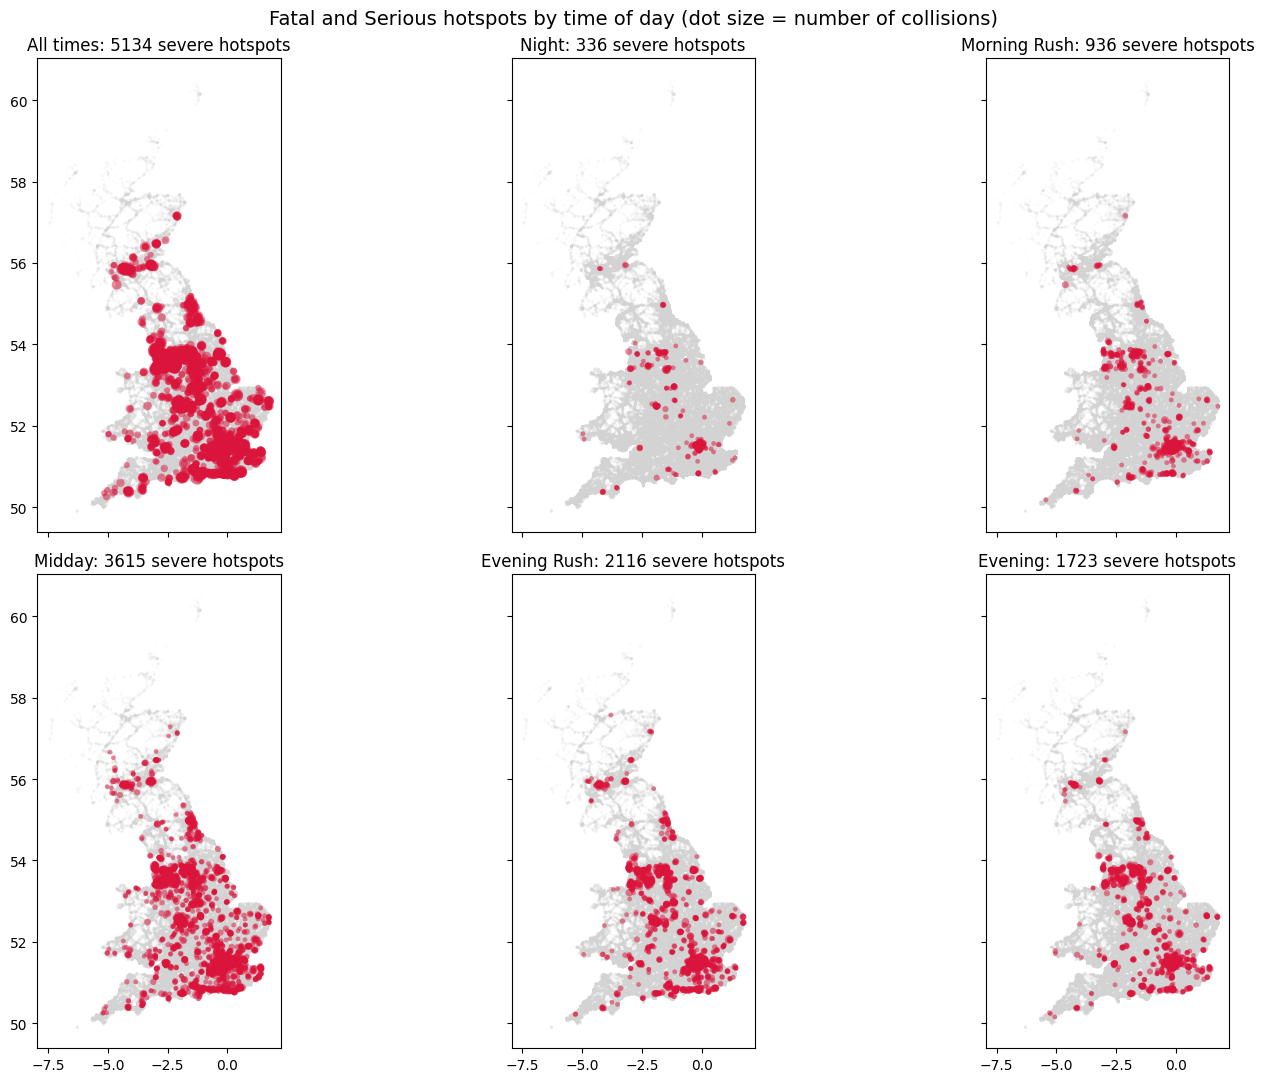

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 11), sharex=True, sharey=True)
for ax, slice_name in zip(axes.ravel(), SLICES):
    h = hot[(hot.subset == "severe") & (hot.slice == slice_name) & hot.month.isna()]
    ax.scatter(df.longitude, df.latitude, s=0.05, color="lightgrey", alpha=0.3)
    ax.scatter(h.longitude, h.latitude, s=h.collisions * 4, alpha=0.5, color="crimson", edgecolor="none")
    ax.set_title(f"{slice_name}: {len(h)} severe hotspots")
    ax.set_aspect(1 / np.cos(np.radians(54)))
fig.suptitle("Fatal and Serious hotspots by time of day (dot size = number of collisions)", fontsize=14)
plt.tight_layout()
plt.show()

**Reading the tables and maps**
- Every compact hotspot is kept. In the run summary above, `found` is every cluster the method found and `compact` is how many were within the radius limit. Hotspots cover only part of the collisions: most collisions are isolated and belong to no hotspot.
- Night and Morning Rush hold few collisions, and so does each single month, so their hotspots are fewer and smaller. The minimum cluster size was lowered for every time slice and month for this reason.
- Many severe hotspots have only 3 to 7 collisions. They get the label "Too few to judge", because a persistence label needs at least 8 collisions.
- Collisions in early 2021 were lower than other years, probably because of the lockdown, so the yearly counts for 2021 should be read with care.
- A hotspot is a statistical concentration of collisions in the past. It does not predict a future crash and does not by itself show a cause.

## 7. Download the results

In [13]:
to_download = [OUT_FILE, PROFILE_FILE, OUT_DIR / "method_comparison.csv"]
try:
    from google.colab import files
    for f in to_download:
        files.download(str(f))
except ImportError:
    print("Not running in Colab. The files are in:", OUT_DIR)
    for f in to_download:
        print(" ", f)

Not running in Colab. The files are in: /content/spatial_temporal
  /content/spatial_temporal/hotspots.json
  /content/spatial_temporal/hotspot_profiles.json.gz
  /content/spatial_temporal/method_comparison.csv


**After downloading**
1. Copy `hotspots.json` and `hotspot_profiles.json.gz` to `results/spatial_temporal/` in the repo.
2. Check them against the backend contract: `python tools\validate_hotspots.py results\spatial_temporal\hotspots.json` (the tool needs the version 2 update).
3. Restart the backend. `/api/hotspots/meta` should now show the method, the generated time and `features`.
4. Keep `method_comparison.csv` for the report.